## Random Forest

## Model Building

In [2]:
# Importing the necessary module!

import numpy as np
import pandas as pd

In [2]:
# Importing data

df = pd.read_csv("datasets/banking.csv")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,59,retired,married,high.school,unknown,no,yes,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.866,5228.1,0
41184,31,housemaid,married,basic.4y,unknown,no,no,telephone,may,thu,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0
41185,42,admin.,single,university.degree,unknown,yes,yes,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
41186,48,technician,married,professional.course,no,no,yes,telephone,oct,tue,...,2,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,0


In [4]:
categorical_cols = ['job', 'marital', 'education', 
                    'default', 'housing', 'loan', 'contact',
                    'month', 'day_of_week', 'poutcome']

X = df.drop("y", axis=1)
y = df["y"]

In [6]:
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)


In [20]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    criterion="gini",
    n_estimators=10,            
    min_samples_leaf=2,      
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=2, n_estimators=10, random_state=42)

In [21]:
y_pred = model_rf.predict(X_test)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.9090394108602412


Trees: 1 ; Accuracy: 0.89
Trees: 2 ; Accuracy: 0.9
Trees: 3 ; Accuracy: 0.9
Trees: 4 ; Accuracy: 0.9
Trees: 5 ; Accuracy: 0.91
Trees: 6 ; Accuracy: 0.91
Trees: 7 ; Accuracy: 0.91
Trees: 8 ; Accuracy: 0.91


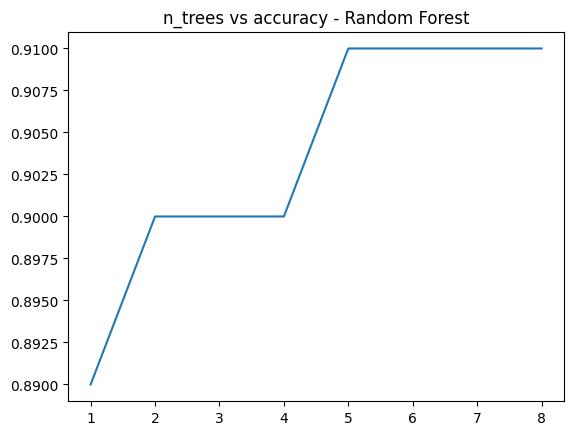

In [ ]:

import matplotlib.pyplot as plt
for depth in range(5,10):

    trees = []
    accuracy = []
    for n_tree in range(1, 9):

        model_rf = RandomForestClassifier(
        criterion="gini",
        n_estimators=n_tree,            
        min_samples_leaf=2,      
        random_state=42
        )
        model_rf.fit(X_train, y_train)
        y_pred = model_rf.predict(X_test)
        trees.append(n_tree)
        accuracy.append(round(accuracy_score(y_test, y_pred),2))
        print(f'Trees: {n_tree} ; Accuracy: {round(accuracy_score(y_test, y_pred),2)}')
        

    plt.plot(np.array(trees), np.array(accuracy))
    plt.title("n_trees vs accuracy - Random Forest")
    plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,              
    min_samples_leaf=2,      
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, random_state=42)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
                            random_state=0
                            )
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
from sklearn.metrics import accuracy_score
print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.9144


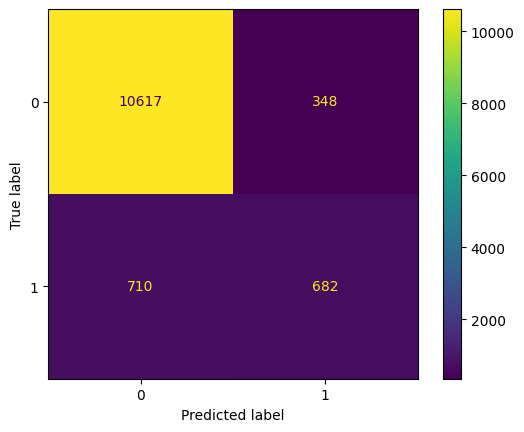

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)
